# 导入环境

In [8]:

import os
from dotenv import load_dotenv

load_dotenv("/evn")
api_key = os.getenv("SILICON_FLOW")
base_url = os.getenv("SILICON_URL")
api_tavily = os.getenv("api_tavily")


# 定义state节点
> 节点和节点进行通信的数据

- TypeDict: python标准库,只执行静态检查
- pydatnic:进行运行检查和序列化功能

In [9]:
from pydantic import BaseModel,Field
from langchain.messages import AIMessage

class State(BaseModel):
    messages:list[AIMessage] = Field(default_factory=list,description="The message to be sent to the agent")
    extra_field:int = Field(default=0)


# 定义一个节点

In [20]:
def node(state:State):
    messages = state.messages
    new_message = AIMessage(content="hello,i am node 1")

    return {
        "messages":messages+[new_message],
        "extra_field":1
    }

# 创建一个图

In [21]:
from langgraph.graph import StateGraph,END,START


graph = StateGraph(State)
graph.add_node("node1",node)


graph.add_edge(START,"node1")
graph.add_edge("node1",END)
graph_builder = graph.compile()



查看图结构

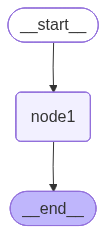

In [22]:
from IPython.display import Image,display

display(Image(graph_builder.get_graph().draw_mermaid_png()))

# 调用

In [23]:
from langchain_core.messages import AIMessage,HumanMessage

result = graph_builder.invoke(State(messages=[HumanMessage(content="hello")]))

print(result)

{'messages': [AIMessage(content='hello', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), AIMessage(content='hello,i am node 1', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])], 'extra_field': 1}


In [25]:
from langchain_core.messages import HumanMessage

for message in result["messages"]:
    message.pretty_print()

================================== Ai Message ==================================

hello
================================== Ai Message ==================================

hello,i am node 1
